<a href="https://colab.research.google.com/github/mib-a/ML-DL/blob/main/3%20Deep%20Learning/DL%20Projects/FMNIST/P02_ANN_Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 👗 Smart Fashion AI with Neural Networks

---

## 📖 Story: StyleAI — Smart Fashion Recognition

You've just joined **StyleAI**, a startup building an AI-powered wardrobe assistant app. The app lets users snap a photo of any clothing item and instantly classifies it. Your job is to build the **image classification model** that powers this feature.

The dataset is **Fashion-MNIST** — 28×28 grayscale images of 10 clothing categories:

| Label | Class Name |
|-------|------------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |


## Load & Explore the Data

### 2.1 Download the Dataset (1 Marks)

We will use `torchvision.datasets.FashionMNIST` to download the dataset. This is similar to how we loaded data from `.npy` files in class, but here PyTorch handles the download for us.

Run the cell below to download the training and test sets:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import numpy as np
import matplotlib.pyplot as plt

# Class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Download Fashion-MNIST — this downloads the data into a ./data folder
# download=True means it will download if not already present
full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)
test_dataset_raw = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True)

train_images_all = full_train_dataset.data.numpy()  # shape: (60000, 28, 28)
train_labels_all = full_train_dataset.targets.numpy()  # shape: (60000,)
test_images_all = test_dataset_raw.data.numpy()
test_labels_all = test_dataset_raw.targets.numpy()

print(f"\nTraining set size: {len(full_train_dataset)}")
print(f"Test set size: {len(test_dataset_raw)}")
print(f"Image shape: {full_train_dataset[0][0].size}")


Training set size: 60000
Test set size: 10000
Image shape: (28, 28)


### 2.2 Visualize Sample Images (5 Marks)

Create a **2×5 subplot figure** (figsize 12×5) showing one sample image from **each of the 10 classes**.

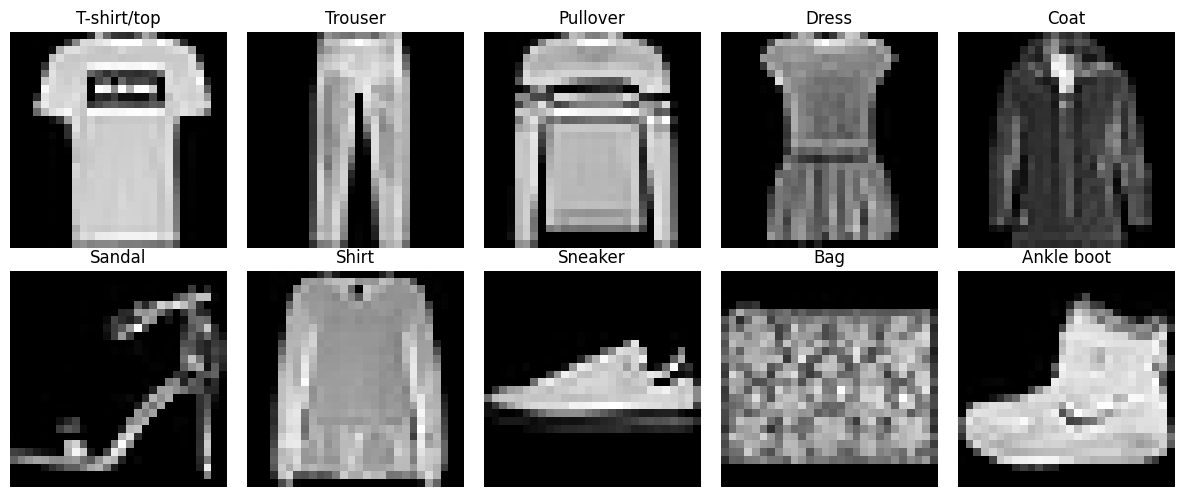

In [ ]:
fig, axes = plt.subplots(2, 5, figsize = (12, 5))
axes = axes.flatten()

for i in range(10):
  axes[i].imshow(train_images_all[train_labels_all == i][0], cmap='gray') # train_image[class_i][0] == first image of all images belonging to class i
  axes[i].set_title(class_names[i])
  axes[i].axis('off')

plt.tight_layout()
plt.show()

## Data Visualization

all the unique label's indexes, count of each: 
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))



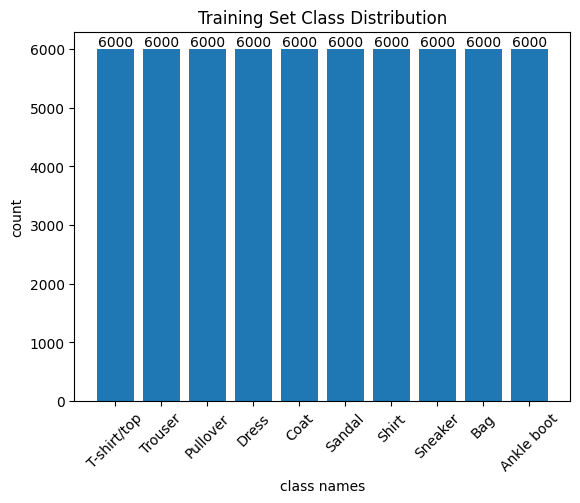

In [ ]:
# YOUR CODE HERE

# counting the num of each class labels
labels, counts = np.unique(train_labels_all, return_counts=True)
print(f"all the unique label's indexes, count of each: \n{labels, counts}\n")


# plotting the bar chart
bars = plt.bar([class_names[i] for i in labels], counts)
# bars var differently to label each bar after
# plt.bar(x, y): calling each index in labels and the count according to that label
plt.title('Training Set Class Distribution')
plt.xlabel('class names')
plt.ylabel('count')
plt.xticks(rotation=45) # was overlapping the labels before

# Adding the count number above each bar
plt.bar_label(bars)

plt.show()

### 2.4 Prepare Tensors and Split (4 Marks)

Now we need to extract the data as NumPy arrays, normalize it, split it, and convert to PyTorch tensors.


In [ ]:
from sklearn.model_selection import train_test_split

# normalizing by dividing 255.00
train_images_all = train_images_all / 255.0
test_images_all = test_images_all / 255.0

# train test split : 10000/60000 = 1/6; decimal doesnt work (as irrational)
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(train_images_all, train_labels_all, test_size = 1/6, random_state = 42)

# Converting all ndarray to Tensors
X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.long)
X_val = torch.tensor(X_val_np, dtype=torch.float32)
y_val = torch.tensor(y_val_np, dtype=torch.long)
X_test = torch.tensor(test_images_all, dtype=torch.float32)
y_test = torch.tensor(test_labels_all, dtype=torch.long)


In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
assert X_train.shape == (50000, 28, 28), f"Expected X_train shape (50000, 28, 28), got {X_train.shape}"
assert X_val.shape == (10000, 28, 28), f"Expected X_val shape (10000, 28, 28), got {X_val.shape}"
assert X_train.dtype == torch.float32, "X_train should be float32"
assert y_train.dtype == torch.long, "y_train should be long"
assert X_train.max() <= 1.0 and X_train.min() >= 0.0, "Pixel values should be in [0, 1]"
print("✅ Q2.4 Passed!")
print(f"   Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

✅ Q2.4 Passed!
   Train: torch.Size([50000, 28, 28]), Val: torch.Size([10000, 28, 28]), Test: torch.Size([10000, 28, 28])


---

## Question 3: Build DataLoaders (10 Marks)

Create `TensorDataset` and `DataLoader` objects for the train, validation, and test sets.

- **batch_size = 64**
- **shuffle = True** for training, **False** for validation and test


In [ ]:
# Creating TensorDataset
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# Creating DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
batch_X, batch_y = next(iter(train_loader))
assert batch_X.shape == (64, 28, 28), f"Batch shape should be (64, 28, 28), got {batch_X.shape}"
assert batch_y.dtype == torch.long, "Labels should be torch.long"
assert batch_X.max() <= 1.0, "Images should be normalized"
print("✅ Q3 Passed!")
print(f"   Batch images shape: {batch_X.shape}")
print(f"   Batch labels shape: {batch_y.shape}")

✅ Q3 Passed!
   Batch images shape: torch.Size([64, 28, 28])
   Batch labels shape: torch.Size([64])


---

## Question 4: Define the Model (15 Marks)

Create a class `FashionClassifier` inheriting from `nn.Module`.

Use `nn.Sequential` with this architecture:

| Layer | Description |
|-------|-------------|
| Flatten | Convert 28×28 → 784 |
| Linear | 784 → 256 |
| ReLU | Activation |
| Linear | 256 → 128 |
| ReLU | Activation |
| Linear | 128 → 64 |
| ReLU | Activation |
| Linear | 64 → 10 |




In [ ]:
# Creating the class
class FashionClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    # Forward Pass
    def forward(self, features):
        output = self.network(features)
        return output

# creating the model instance
model = FashionClassifier(input_size=784, num_classes=10)
print(model)


FashionClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
test_input = torch.randn(5, 28, 28)
test_output = model(test_input)
assert test_output.shape == (5, 10), f"Output shape should be (5, 10), got {test_output.shape}"
total_params = sum(p.numel() for p in model.parameters())
assert total_params > 0, "Model should have trainable parameters"
print("✅ Q4 Passed!")
print(f"   Total parameters: {total_params}")
print(model)

✅ Q4 Passed!
   Total parameters: 242762
FashionClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


---

## Question 5: Train the Model (25 Marks)

### 5.1 Set Up Training (5 Marks)
- Loss function: `nn.CrossEntropyLoss`
- Optimizer: `optim.SGD` with `lr=0.01`
- Number of epochs: **15**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)
epochs = 15


### 5.2 Training Loop (15 Marks)

Write a complete training loop for **15 epochs**.

For each epoch:
- Train on `train_loader` and compute training loss
- Evaluate on `val_loader` (with `torch.no_grad()`) and compute validation loss
- Print: `Epoch {epoch+1}/{epochs} | Train Loss: {:.4f} | Val Loss: {:.4f} `

Store: `train_losses`, `val_losses`, (lists, one value per epoch).

In [ ]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range (epochs): # run the train and validation process for 15 epochs
  current_epoch_train_loss = 0.0
  num_train_batches = 0

  # for calculating accuracies: accuracy = correct/total * 100
  train_correct = 0
  train_total = 0

  for images, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    # calculating training loss
    current_epoch_train_loss += loss.item() # add this batch's training loss to the prev loss
    num_train_batches += 1 # for avg_train_loss (number of batches processed)

    # calculating training accuracy
    predictions = torch.argmax(outputs, dim=1) # index of the highest value'd output
    train_correct += (predictions == labels).sum().item() # how many were correct in this batch
    train_total += labels.size(0) # how many images were processed

# for all batches in this epoch
  avg_train_loss = current_epoch_train_loss / num_train_batches
  train_losses.append(avg_train_loss)

# for training accuracy
  train_accuracy = train_correct / train_total * 100 # accuracy = correct/total * 100
  train_accuracies.append(train_accuracy)


# FOR VALIDATION DATASET
  current_epoch_val_loss = 0.0
  num_val_batches = 0

  val_correct = 0
  val_total = 0

  with torch.no_grad():
    for images, labels in val_loader:
      outputs = model(images)
      loss = criterion(outputs, labels)
      current_epoch_val_loss += loss.item()
      num_val_batches += 1

      # Accuracy
      predictions = torch.argmax(outputs, dim=1)
      val_correct += (predictions == labels).sum().item()
      val_total += labels.size(0)

  avg_val_loss = current_epoch_val_loss / num_val_batches
  val_losses.append(avg_val_loss)

  val_accuracy = val_correct / val_total * 100
  val_accuracies.append(val_accuracy)

  print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch 1/15 | Train Loss: 1.9867 | Val Loss: 1.2640
Epoch 2/15 | Train Loss: 0.9110 | Val Loss: 0.7630
Epoch 3/15 | Train Loss: 0.6879 | Val Loss: 0.8058
Epoch 4/15 | Train Loss: 0.6032 | Val Loss: 0.6624
Epoch 5/15 | Train Loss: 0.5600 | Val Loss: 0.6084
Epoch 6/15 | Train Loss: 0.5279 | Val Loss: 0.5518
Epoch 7/15 | Train Loss: 0.5044 | Val Loss: 0.5234
Epoch 8/15 | Train Loss: 0.4833 | Val Loss: 0.5682
Epoch 9/15 | Train Loss: 0.4642 | Val Loss: 0.4667
Epoch 10/15 | Train Loss: 0.4532 | Val Loss: 0.5536
Epoch 11/15 | Train Loss: 0.4385 | Val Loss: 0.4543
Epoch 12/15 | Train Loss: 0.4288 | Val Loss: 0.4482
Epoch 13/15 | Train Loss: 0.4212 | Val Loss: 0.6355
Epoch 14/15 | Train Loss: 0.4104 | Val Loss: 0.4898
Epoch 15/15 | Train Loss: 0.4026 | Val Loss: 0.4338


In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
assert len(train_losses) == 15, f"Expected 15 epochs, got {len(train_losses)}"
assert len(val_losses) == 15
assert train_losses[-1] < train_losses[0], "Training loss should decrease"
print("✅ Q5.2 Passed!")
print(f"   Final Train Acc: {train_accuracies[-1]:.2f}%, Final Val Acc: {val_accuracies[-1]:.2f}%")

✅ Q5.2 Passed!
   Final Train Acc: 85.87%, Final Val Acc: 84.57%


### 5.3 Test Evaluation (5 Marks)

Evaluate the model on the **test set**. Print the test_accuracy (required_variable)

Also, collect all test predictions and true labels into lists called `all_preds` and `all_labels` (we'll use them for analysis later).

Print: `Test Accuracy: {:.2f}%`

In [ ]:
# YOUR CODE HERE

# Making the prediction
with torch.no_grad():
  y_pred_prob = model(X_test) # logits
y_pred = torch.argmax(y_pred_prob ,dim = 1) # per row which index holds the biggest probability.
# print("\nPrediction: ", y_pred[:10])
# print("Actual:", y_test[:10])

# all_preds & all_labels
all_preds = y_pred.tolist() # y_pred tensor to all_pred list
# print(all_preds)
all_labels = y_test.tolist()

# test accuracy = all accurate predictions (TN + TF) / all samples * 100%
test_accuracy = (y_pred == y_test).float().mean() * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")




Test Accuracy: 83.86%


In [ ]:
# --- TEST CELL (DO NOT MODIFY) ---
assert test_accuracy > 40.0, f"Test accuracy should be > 40%, got {test_accuracy:.2f}%"
assert len(all_preds) == len(X_test), "Predictions should cover all test samples"
print(f"✅ Q5.3 Passed! Test Accuracy: {test_accuracy:.2f}%")

✅ Q5.3 Passed! Test Accuracy: 83.86%


---

## Question 6: Visualize & Analyze Results (25 Marks)

### 6.1 Plot Training Loss vs Validation Loss (5 Marks)

Plot **Training Loss** and **Validation Loss** on the same figure across epochs.
- Include a legend, title ("Loss Curve"), and axis labels.

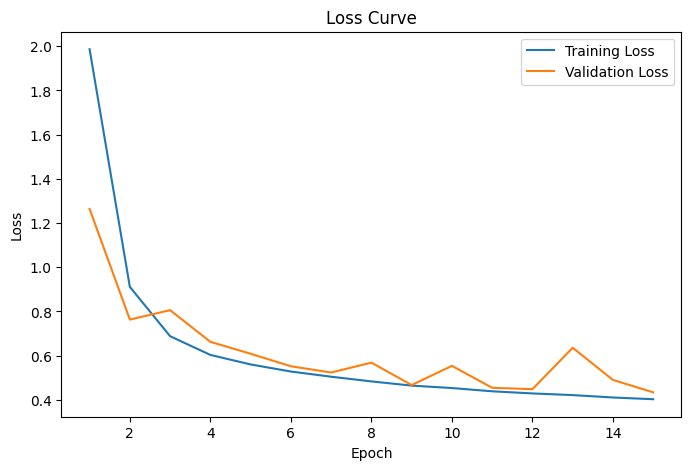

In [ ]:
# YOUR CODE HERE
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label="Training Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

### 6.2 Plot Training Accuracy vs Validation Accuracy (5 Marks)

Plot **Training Accuracy** and **Validation Accuracy** on the same figure across epochs.
- Include a legend, title ("Accuracy Curve"), and axis labels.

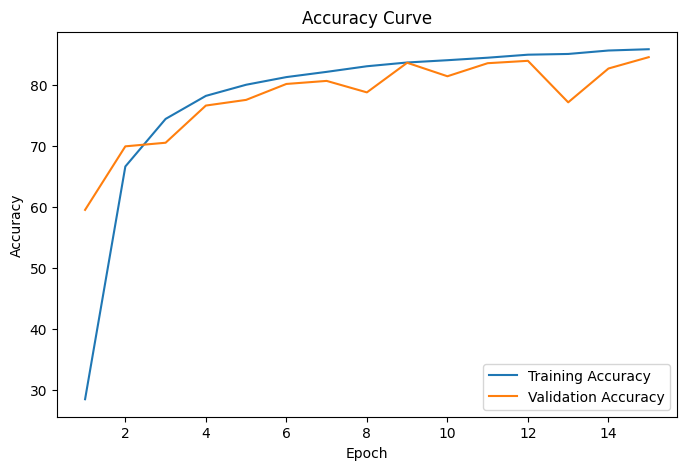

In [ ]:
# YOUR CODE HERE

epochs = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, label="Training Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

### 6.3 Confusion Matrix (5 Marks)

Using `sklearn.metrics`:
1. Compute the confusion matrix on test predictions.
2. Display it as a heatmap using `ConfusionMatrixDisplay` with `class_names` as labels.
3. Title: "StyleAI Fashion Classifier — Test Confusion Matrix"

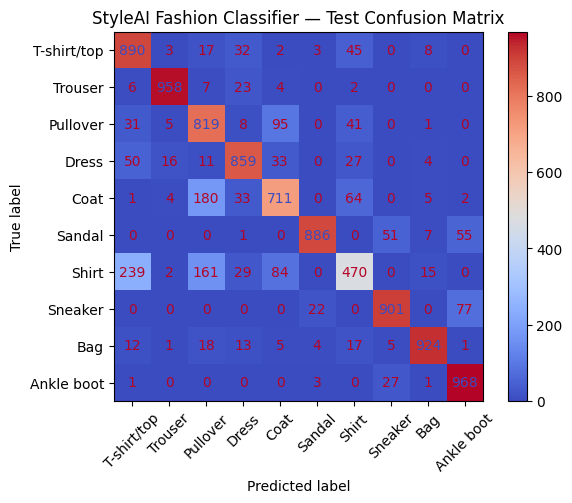

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# YOUR CODE HERE

# Confusion Matrix
confusion_mat = confusion_matrix(y_test, y_pred)

# Heatmap
confusion_mat_display = ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels=class_names)
confusion_mat_display.plot(xticks_rotation=45, cmap="coolwarm")
plt.title("StyleAI Fashion Classifier — Test Confusion Matrix")
plt.show()

### 6.4 Classification Report (5 Marks)

Print the `classification_report` from sklearn using `target_names=class_names`.

In [ ]:
from sklearn.metrics import classification_report

# YOUR CODE HERE
classification_rep = classification_report(y_test, y_pred, target_names=class_names)
print(classification_rep)

              precision    recall  f1-score   support

 T-shirt/top       0.72      0.89      0.80      1000
     Trouser       0.97      0.96      0.96      1000
    Pullover       0.68      0.82      0.74      1000
       Dress       0.86      0.86      0.86      1000
        Coat       0.76      0.71      0.74      1000
      Sandal       0.97      0.89      0.92      1000
       Shirt       0.71      0.47      0.56      1000
     Sneaker       0.92      0.90      0.91      1000
         Bag       0.96      0.92      0.94      1000
  Ankle boot       0.88      0.97      0.92      1000

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



### 6.5 Written Analysis (5 Marks)

In the markdown cell below, answer:
1. Which two classes are **most often confused** with each other? Look at the confusion matrix and explain **why** (think about visual similarity).
2. Is the model **overfitting or underfitting**? How can you tell from the learning curves?

*Double-click here to write your analysis*

**Your Analysis:**
1. From the confusion matrix it can be seen that 228 actual shirts were predicted as pull overs. So these two classes are the most often confused classes. Visually they looks the most identicals with very little element (of the grayscale image amtrix) difference among these 10 classes. also they both are upper body clothes with covered hand and neck area almost same too. So, I think this explains the confusion.
2. The model is a bit overfitting. The train_accuracies of the model was 85.87% and the validation accuracy was 84.57%. So the validation was a bit smaller than the training one. Also from the 6.1 and 6.2 curves we can see the validation's metrices at the final epochs was fluctuating where the train data was more gradual. So the model is overfitting but very mild.